# 00 — Playground (data/raw)

Objetivo:
- Cargar los JSON crudos en `data/raw`.
- Hacer un vistazo rápido (head, tipos, missingness).
- Explorar `price_histories` por mercado.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

raw_dir = Path("../data/raw")
raw_dir

PosixPath('../data/raw')

## 1. Cargar datos

In [2]:
with open(raw_dir / "active_markets.json") as f:
    active = json.load(f)

with open(raw_dir / "resolved_markets.json") as f:
    resolved = json.load(f)

with open(raw_dir / "price_histories.json") as f:
    price_histories = json.load(f)

active_df = pd.DataFrame(active)
resolved_df = pd.DataFrame(resolved)

len(active_df), len(resolved_df), len(price_histories)

(1000, 2000, 1739)

## 2. Vista rápida de los mercados

In [3]:
active_df.head(3)

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,description,outcomes,outcomePrices,volume,active,closed,marketMakerAddress,createdAt,updatedAt,new,...,deploying,deployingTimestamp,rfqEnabled,holdingRewardsEnabled,feesEnabled,requiresTranslation,feeType,negRiskMarketID,oneWeekPriceChange,oneMonthPriceChange,gameStartTime,secondsDelay,sportsMarketType,umaResolutionStatus,eventStartTime,gameId,line,makerBaseFee,takerBaseFee,groupItemRange
0,1386657,"US strikes Iran by February 23, 2026?",0x8a38e9511fe17e13fa7c3fc65923983c22d4d494b690...,us-strikes-iran-by-february-23-2026-678-563,,2026-01-31T00:00:00Z,167339.23974,2026-02-16T20:04:00.242095Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if the US in...","[Yes, No]","[0.0215, 0.9785]",6130619.349931,True,False,,2026-02-16T19:53:14.526921Z,2026-02-23T17:04:56.279306Z,False,...,False,2026-02-16T20:01:40.340289Z,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,654412,Will the Fed decrease interest rates by 50+ bp...,0xdeb615a52cd114e5aa27d8344ae506a72bea81f6ed13...,will-the-fed-decrease-interest-rates-by-50-bps...,,2026-03-18T00:00:00Z,1710068.61436,2025-10-29T19:01:04.738799Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,The FED interest rates are defined in this mar...,"[Yes, No]","[0.0075, 0.9925]",65686313.005961,True,False,,2025-10-28T20:58:04.772334Z,2026-02-23T17:05:32.902319Z,False,...,False,2025-10-29T18:56:38.377975Z,False,False,False,False,NaN,0xfabe717b4c1799d917420cf834a4f1b76b77e90cc0cf...,0.001,-0.004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,654415,Will the Fed increase interest rates by 25+ bp...,0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7c...,will-the-fed-increase-interest-rates-by-25-bps...,,2026-03-18T00:00:00Z,1432641.09527,2025-10-29T19:01:07.490058Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,The FED interest rates are defined in this mar...,"[Yes, No]","[0.0075, 0.9925]",55591624.962036,True,False,,2025-10-28T20:58:06.700202Z,2026-02-23T17:04:30.373362Z,False,...,False,2025-10-29T18:56:38.383714Z,False,False,False,False,NaN,0xfabe717b4c1799d917420cf834a4f1b76b77e90cc0cf...,0.002,-0.004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
resolved_df.head(3)

,id,question,conditionId,slug,endDate,startDate,image,icon,description,outcomes,outcomePrices,volume,active,closed,marketMakerAddress,createdAt,updatedAt,closedTime,new,featured,...,holdingRewardsEnabled,feesEnabled,requiresTranslation,feeType,resolutionSource,seriesColor,liquidity,liquidityNum,liquidityAmm,liquidityClob,competitive,oneWeekPriceChange,oneMonthPriceChange,oneHourPriceChange,clobRewards,negRiskMarketID,groupItemRange,volume24hr,volume24hrClob,gameStartTime
0,1361753,Espresso FDV above $50M one day after launch?,0x4a9b850ef016a97ee4347a7fe91dc5bb0dd6ba7a9f33...,espresso-fdv-above-50m-one-day-after-launch,2028-01-01T05:00:00Z,2026-02-10T00:43:23.697427Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if the Fully...","[Yes, No]","[1, 0]",83280.457952,True,True,,2026-02-10T00:40:50.509127Z,2026-02-15T00:26:02.410732Z,2026-02-14 00:11:35+00,False,False,...,False,False,False,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1361755,Espresso FDV above $300M one day after launch?,0x37e570f6defa9b72e96c7166d96fdc7b56a074010c5a...,espresso-fdv-above-300m-one-day-after-launch-4...,2028-01-01T05:00:00Z,2026-02-10T00:43:25.580825Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if the Fully...","[Yes, No]","[0, 1]",140357.76276,True,True,,2026-02-10T00:40:51.639904Z,2026-02-15T00:26:03.904721Z,2026-02-14 00:12:37+00,False,False,...,False,False,False,None,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1366813,Espresso FDV above $200M one day after launch?,0x374e86da7257106731513b2b381ac247ceed0b0f76c0...,espresso-fdv-above-200m-one-day-after-launch-424,2028-01-01T05:00:00Z,2026-02-11T18:47:30.941683Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,"This market will resolve to ""Yes"" if the Fully...","[Yes, No]","[1, 0]",136127.009099,True,True,,2026-02-11T18:44:40.97421Z,2026-02-15T00:26:00.915316Z,2026-02-14 00:15:41+00,False,False,...,False,False,False,None,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Campos clave, tipos y missingness

In [5]:
key_fields = [
    "id", "question", "slug", "outcomes", "outcomePrices", "clobTokenIds",
    "volume", "volume24hr", "liquidity", "bestBid", "bestAsk", "spread",
    "active", "closed", "resolution", "resolutionSource", "endDate",
    "startDate", "createdAt", "updatedAt", "closedTime", "negRisk",
]

def summarize(df):
    rows = []
    for f in key_fields:
        if f in df.columns:
            series = df[f]
            example = series.dropna().iloc[0] if series.notna().any() else None
            rows.append({
                "field": f,
                "dtype": series.dtype,
                "nonnull": int(series.notna().sum()),
                "example": str(example)[:80],
            })
        else:
            rows.append({"field": f, "dtype": None, "nonnull": 0, "example": None})
    return pd.DataFrame(rows)

summarize(active_df)

,field,dtype,nonnull,example
0,id,str,1000,1386657
1,question,str,1000,"US strikes Iran by February 23, 2026?"
2,slug,str,1000,us-strikes-iran-by-february-23-2026-678-563
3,outcomes,object,1000,"['Yes', 'No']"
4,outcomePrices,object,1000,"['0.0215', '0.9785']"
5,clobTokenIds,object,1000,['10095973888358805654962971327252401506291961...
6,volume,str,1000,6130619.349931
7,volume24hr,float64,1000,3497150.9813040043
8,liquidity,str,1000,167339.23974
9,bestBid,float64,885,0.02


In [6]:
summarize(resolved_df)

,field,dtype,nonnull,example
0,id,str,2000,1361753
1,question,str,2000,Espresso FDV above $50M one day after launch?
2,slug,str,2000,espresso-fdv-above-50m-one-day-after-launch
3,outcomes,object,2000,"['Yes', 'No']"
4,outcomePrices,object,2000,"['1', '0']"
5,clobTokenIds,object,2000,['96267458254090441798245236969531476202789337...
6,volume,str,2000,83280.457952
7,volume24hr,float64,75,7254.29
8,liquidity,str,243,0
9,bestBid,float64,492,0.999


## 4. Price histories (dict por market_id)

In [21]:
lengths = pd.Series({mid: len(hist) for mid, hist in price_histories.items()})
lengths.describe()

count    1739.000000
mean      367.168488
std       273.578908
min         2.000000
25%       125.000000
50%       268.000000
75%       713.500000
max       741.000000
dtype: float64

In [30]:
import random

sample_market_id = random.choice(list(price_histories.keys()))
print("sample_market_id:", sample_market_id)

hist_df = pd.DataFrame(price_histories[sample_market_id])

if not hist_df.empty:
    hist_df["timestamp"] = pd.to_datetime(hist_df["t"], unit="s", utc=True)
    hist_df.head(5)
else:
    hist_df

sample_market_id: 840944


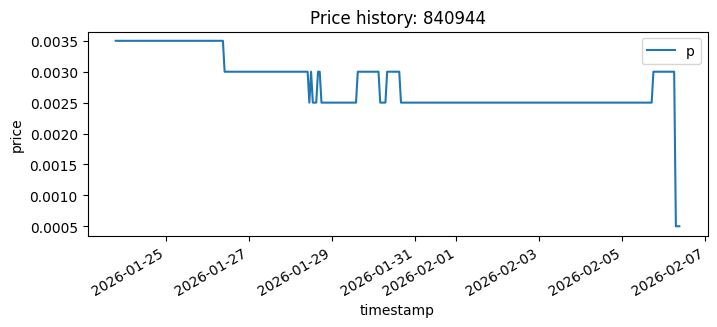

In [31]:
if not hist_df.empty:
    ax = hist_df.plot(x="timestamp", y="p", figsize=(8, 3), title=f"Price history: {sample_market_id}")
    ax.set_xlabel("timestamp")
    ax.set_ylabel("price")
    plt.show()

## 5. Lookup rápido por market_id

In [10]:
market_id = sample_market_id  # cambia esto por un ID que te interese

row = active_df.loc[active_df["id"] == market_id]
if not row.empty:
    display(row.iloc[0])
else:
    row = resolved_df.loc[resolved_df["id"] == market_id]
    display(row.iloc[0]) if not row.empty else f"No encontrado: {market_id}"

id                                                           1361753
question               Espresso FDV above $50M one day after launch?
conditionId        0x4a9b850ef016a97ee4347a7fe91dc5bb0dd6ba7a9f33...
slug                     espresso-fdv-above-50m-one-day-after-launch
endDate                                         2028-01-01T05:00:00Z
                                         ...                        
negRiskMarketID                                                  NaN
groupItemRange                                                   NaN
volume24hr                                                       NaN
volume24hrClob                                                   NaN
gameStartTime                                                    NaN
Name: 0, Length: 96, dtype: object

## 6. Notas y próximos pasos

- Si quieres explorar columnas nuevas, añade aquí celdas con filtros o plots.
- Para features y entrenamiento, usa los notebooks 01–04.